# Exploring Data Distributions and Visual Patterns Using EDA Techniques

Task 1:

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Histogram with 5 bins

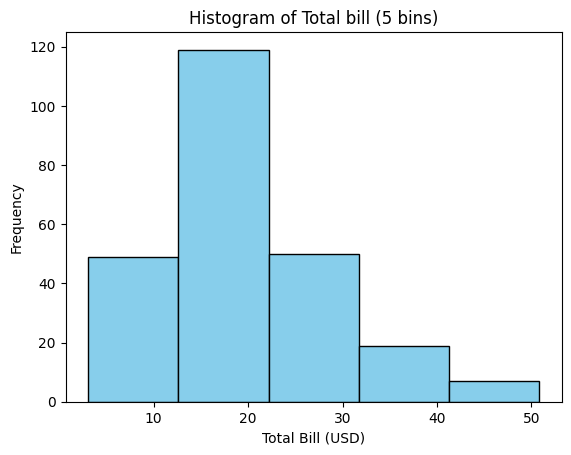

In [2]:
plt.hist(df["total_bill"], bins = 5, color = "skyblue", edgecolor = "black")
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Total bill (5 bins)")
plt.show()

Histogram with 20 bins

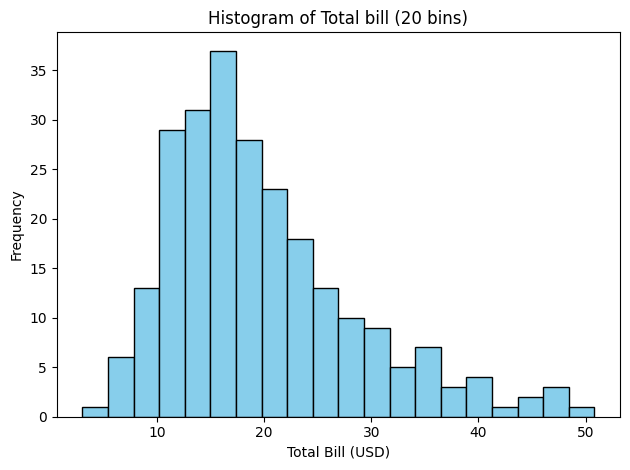

In [4]:
plt.hist(df["total_bill"], bins = 20, color = "skyblue", edgecolor = "black")
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Total bill (20 bins)")
plt.tight_layout()
plt.show()

1. Distribution shape:

*   The distribution of total_bill is right-skewed (positively skewed).
*   Most bills are concentrated in lower values (approx. 10 to 20 USD).
*   A long tail extends toward higher bills (approx. 40 to 50 USD).

2. Effect of bin size:

* 5 bins:
  * Gives a high-level summary but hides finer details.
  * Distribution looks smoother but less precise.
* 20 bins:
  * Reveals clusters, gaps.
  * Better for detecting skewness and spread.

Task 2:

/tmp/ipykernel_1267/2126550082.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




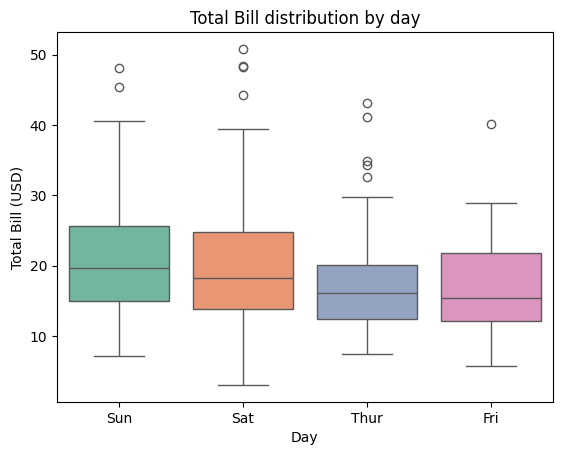

In [7]:
sns.boxplot(data = df, x="day", y="total_bill", palette="Set2", legend=False)
plt.xlabel("Day")
plt.ylabel("Total Bill (USD)")
plt.title("Total Bill distribution by day")

plt.show()

Sunday shows the highest median total bill

In [14]:
grouped = df.groupby("day")

sun = grouped.get_group("Sun")

Q1 = sun["total_bill"].quantile(0.25)
Q3 = sun["total_bill"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = sun[(sun["total_bill"] < lower_bound) | (sun["total_bill"] > upper_bound)]

Q1, Q3, IQR, lower_bound, upper_bound, outliers

(np.float64(14.987499999999999),
 np.float64(25.5975),
 np.float64(10.610000000000001),
 np.float64(-0.9275000000000038),
 np.float64(41.5125),
      total_bill  tip   sex smoker  day    time  size
 156       48.17  5.0  Male     No  Sun  Dinner     6
 182       45.35  3.5  Male    Yes  Sun  Dinner     3)

Task 3:

In [16]:
!pip install plotly


In [17]:
import plotly.express as px

fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="time",
    hover_data=["day", "size"],
    title="Total Bill vs Tip (Lunch vs Dinner)"
)

fig.show()

1. If the bill amount is high then the tip amount is also high. Bill and tip amounts varies with respective to different customers.

2. Dinner transactions are more with higher bill amount, wider spread. Lunch bills are smaller, tightly spread.

3. If we take the data point of bill amount = 44.3, their tip amount = 2.5 which is low. May be the customers didn't like the food or there is a poor service from the hotel